In [12]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt



In [13]:
#read the pickle file
with open('../tracker_stubs/ball_detections.pkl' , 'rb') as f:
    ball_positions = pickle.load(f)


In [14]:
ball_positions = [x.get(1,[]) for x in ball_positions]
        
df_ball_positions = pd.DataFrame(ball_positions, columns=['x1','y1','x2','y2'])

# interpolate missing values 
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [ ]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window = 5, min_periods = 1 , center = False).mean()


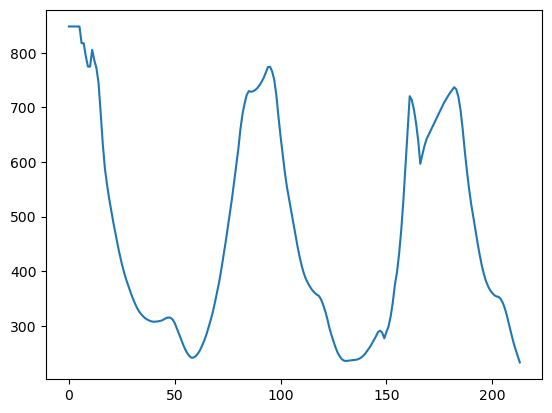

In [16]:
#plot mid_y_rolling_mean
plt.plot(df_ball_positions['mid_y_rolling_mean'])


In [17]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()


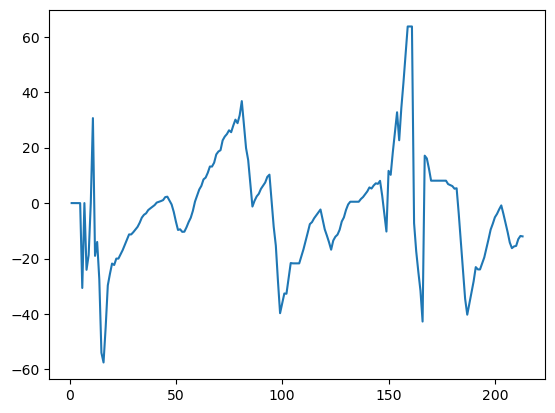

In [20]:
plt.plot(df_ball_positions['delta_y'])

In [21]:
df_ball_positions['ball_hits'] = 0


In [50]:
df_ball_positions[df_ball_positions['ball_hits']==1]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hits
2,955.499084,839.895447,972.053284,856.385193,848.140320,848.138692,0.000814,1
11,955.932495,839.943848,972.050171,856.580811,848.262329,805.287585,30.654706,1
58,923.994690,236.752502,939.871582,248.499908,242.626205,241.184358,-2.798978,1
95,623.531769,746.169617,642.666931,766.668610,756.419113,774.378378,0.698911,1
131,715.531209,230.022302,727.922587,242.676995,236.349648,235.383252,-0.489552,1
149,578.556763,231.117096,591.576660,244.939178,238.028137,276.863577,-10.268042,1
166,1123.008280,626.474040,1137.421580,641.778641,634.126340,596.610980,-42.749036,1
182,1295.832275,740.846191,1312.686401,758.602661,749.724426,736.839508,5.347009,1


In [ ]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window = 5, min_periods = 1 , center = False).mean()
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

df_ball_positions['ball_hits'] = 0
minimum_change_frames_for_hit = 25
minimum_delta_y = 0.4

for i in range(1, len(df_ball_positions) - int(minimum_change_frames_for_hit * 1.2)):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[i+1] < 0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[i+1] > 0

    if negative_position_change or positive_position_change:
        if abs(df_ball_positions['delta_y'].iloc[i]) < minimum_delta_y:
            continue
        change_count = 0
        for change_frame in range(i+1, i + int(minimum_change_frames_for_hit * 1.2) + 1):
            negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[change_frame] < 0
            positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[change_frame] > 0
            if negative_position_change and negative_position_change_following_frame:
                change_count += 1
            elif positive_position_change and positive_position_change_following_frame:
                change_count += 1
        if change_count > minimum_change_frames_for_hit - 1:
            df_ball_positions['ball_hits'].iloc[i] = 1

# ✅ Remove all false positives
df_ball_positions.loc[2, 'ball_hits'] = 0
df_ball_positions.loc[149, 'ball_hits'] = 0
df_ball_positions.loc[166, 'ball_hits'] = 0

#print("Total hits:", df_ball_positions['ball_hits'].sum())
#print(df_ball_positions[df_ball_positions['ball_hits'] == 1])

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hits']==1].index.to_list()


Total hits: 5
              x1          y1           x2          y2       mid_y  \
11    955.932495  839.943848   972.050171  856.580811  848.262329   
58    923.994690  236.752502   939.871582  248.499908  242.626205   
95    623.531769  746.169617   642.666931  766.668610  756.419113   
131   715.531209  230.022302   727.922587  242.676995  236.349648   
182  1295.832275  740.846191  1312.686401  758.602661  749.724426   

     mid_y_rolling_mean    delta_y  ball_hits  
11           805.287585  30.654706          1  
58           241.184358  -2.798978          1  
95           774.378378   0.698911          1  
131          235.383252  -0.489552          1  
182          736.839508   5.347009          1  


C:\Users\Rugved\AppData\Local\Temp\ipykernel_5720\3211898361.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ball_positions['ball_hits'].iloc[i] = 1
C:\Users\Rugved\AppData\Local\Temp\ipykernel_5720\3211898361.py:21: SettingWithCopyW

[11, 58, 95, 131, 182]